In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [3]:
df = pd.read_excel('imdb_scrapper.xlsx')

In [4]:
print(df.shape)
print(df.info())
print(df.head())

(301, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Rank                301 non-null    int64  
 1   Title               301 non-null    object 
 2   Genre               301 non-null    object 
 3   Description         301 non-null    object 
 4   Director            301 non-null    object 
 5   Actors              301 non-null    object 
 6   Year                301 non-null    int64  
 7   Runtime (Minutes)   301 non-null    int64  
 8   Rating              301 non-null    float64
 9   Votes               301 non-null    int64  
 10  Revenue (Millions)  271 non-null    float64
 11  Metascore           284 non-null    float64
dtypes: float64(3), int64(4), object(5)
memory usage: 28.3+ KB
None
   Rank                    Title                     Genre  \
0     1  Guardians of the Galaxy   Action,Adventure,Sci-Fi   
1     2

In [5]:
print(df.isnull().sum())

Rank                   0
Title                  0
Genre                  0
Description            0
Director               0
Actors                 0
Year                   0
Runtime (Minutes)      0
Rating                 0
Votes                  0
Revenue (Millions)    30
Metascore             17
dtype: int64


In [6]:
df.dropna(inplace=True)


In [7]:
df['Revenue (Millions)'] = df['Revenue (Millions)'].fillna(df['Revenue (Millions)'].median())
df['Metascore'] = df['Metascore'].fillna(df['Metascore'].median())

In [8]:
df['Year'] = df['Year'].astype(int)
df['Runtime (Minutes)'] = df['Runtime (Minutes)'].astype(int)

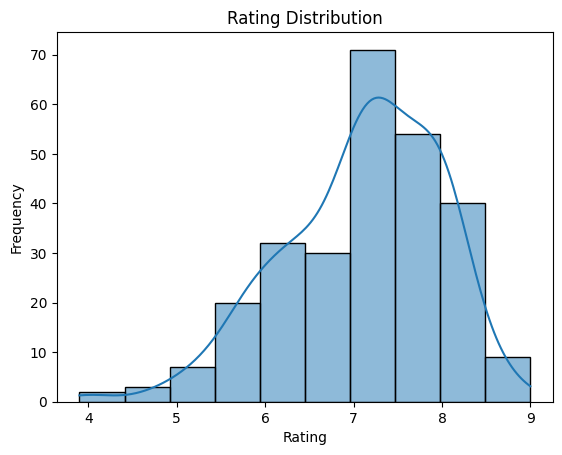

In [9]:
sns.histplot(df['Rating'], bins=10, kde=True)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()


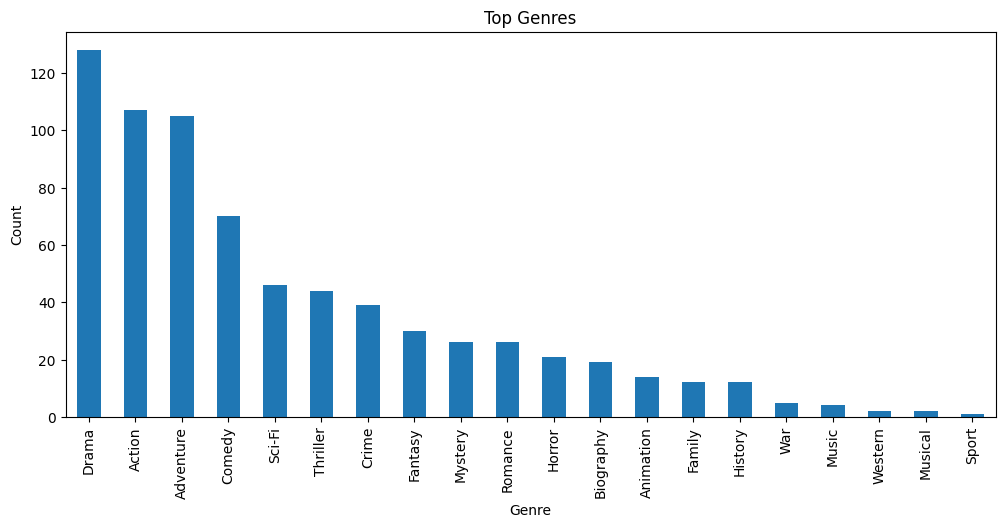

In [10]:
df['Genre'].str.split(',').explode().value_counts().plot(kind='bar', figsize=(12, 5), title="Top Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()


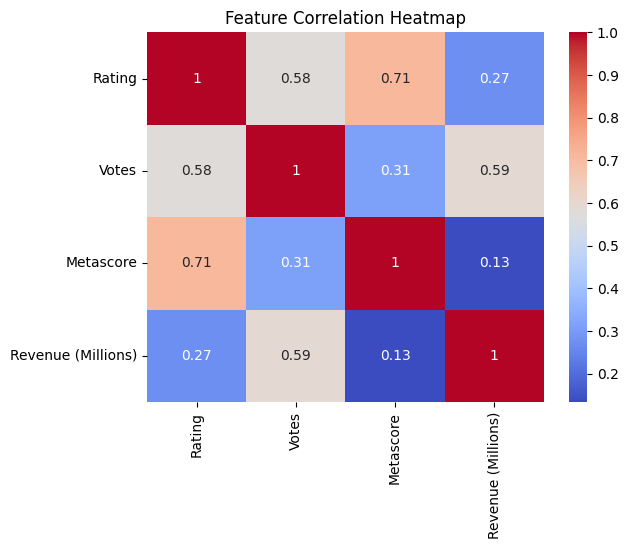

In [11]:
sns.heatmap(df[['Rating', 'Votes', 'Metascore', 'Revenue (Millions)']].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()


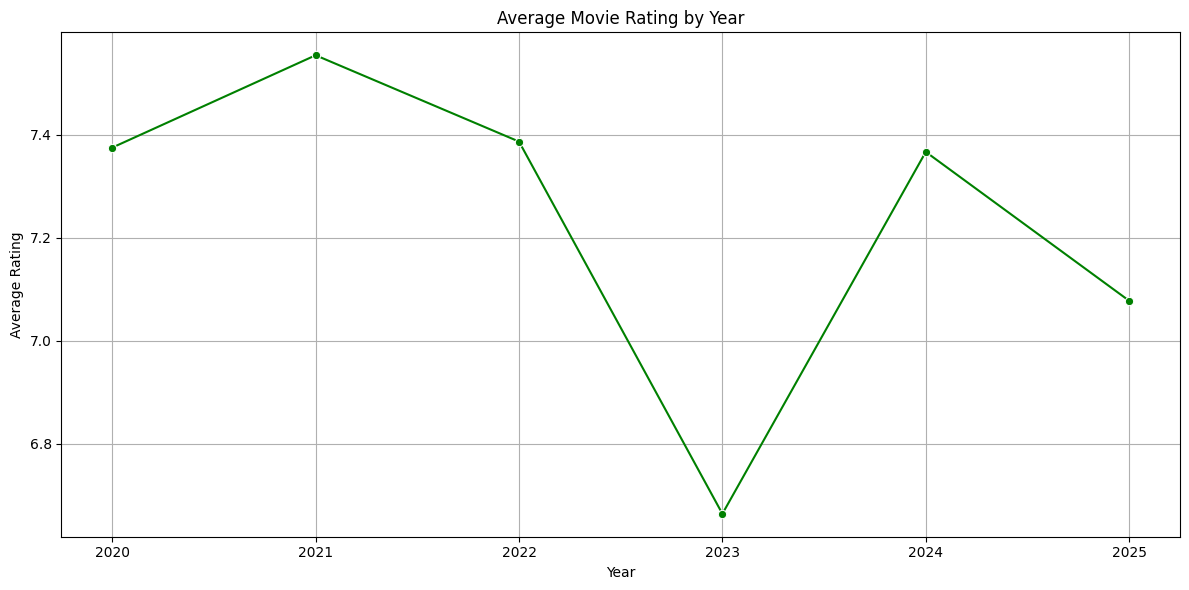

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('imdb_scrapper.xlsx')
df['Year'] = df['Year'].astype(str).str.extract(r'(\d{4})').astype(int)
def ratings_over_time(df):
    year_rating = df.groupby('Year')['Rating'].mean().reset_index()

    plt.figure(figsize=(12, 6))
    sns.lineplot(data=year_rating, x='Year', y='Rating', marker='o', color='green')
    plt.title("Average Movie Rating by Year")
    plt.ylabel("Average Rating")
    plt.xlabel("Year")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
ratings_over_time(df)


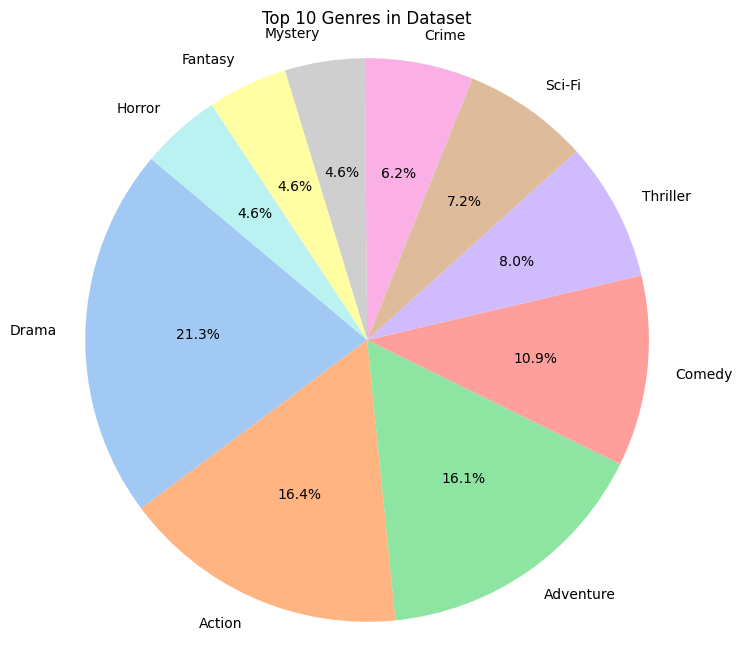

In [13]:
def genre_pie_chart():
    genre_series = df['Genre'].dropna().str.split(',').explode().str.strip()
    genre_counts = genre_series.value_counts().head(10) 

    plt.figure(figsize=(8, 8))
    plt.pie(genre_counts, labels=genre_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
    plt.title("Top 10 Genres in Dataset")
    plt.axis('equal')
    plt.show()

genre_pie_chart()


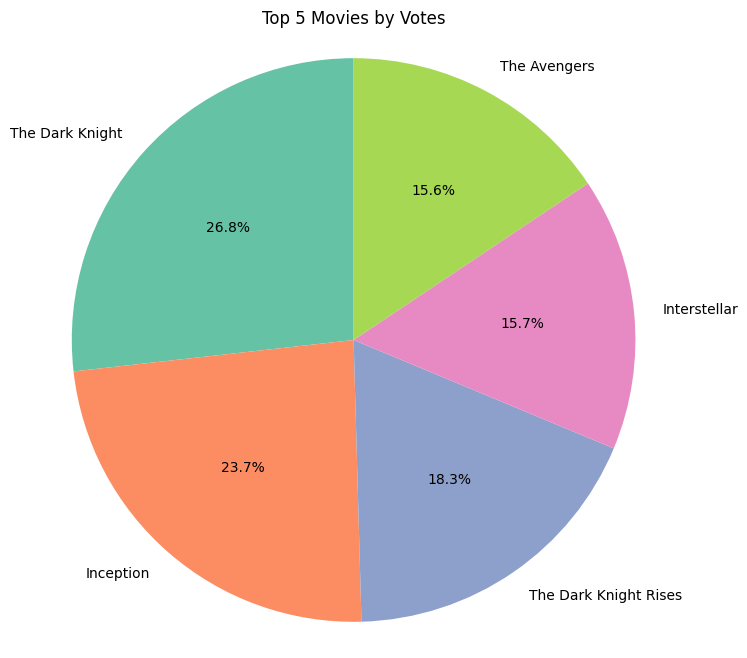

In [14]:
def vote_pie_chart():
    top_movies = df.sort_values(by='Votes', ascending=False).head(5)

    plt.figure(figsize=(8, 8))
    plt.pie(top_movies['Votes'], labels=top_movies['Title'], autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set2'))
    plt.title("Top 5 Movies by Votes")
    plt.axis('equal')
    plt.show()

vote_pie_chart()


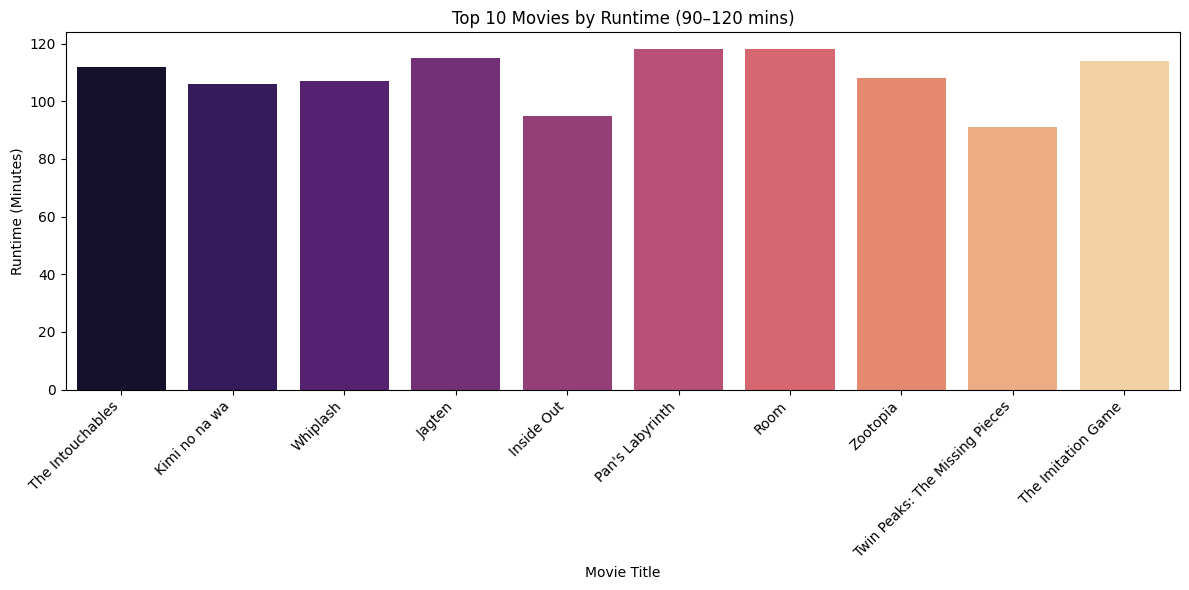

,Title,Runtime (Minutes),Rating
249,The Intouchables,112,8.6
96,Kimi no na wa,106,8.6
133,Whiplash,107,8.5
300,Jagten,115,8.3
241,Inside Out,95,8.2
230,Pan's Labyrinth,118,8.2
143,Room,118,8.2
74,Zootopia,108,8.1
154,Twin Peaks: The Missing Pieces,91,8.1
198,The Imitation Game,114,8.1


In [15]:
def recommend_by_runtime(min_time=90, max_time=120):
    filtered = df[(df['Runtime (Minutes)'] >= min_time) & (df['Runtime (Minutes)'] <= max_time)]
    top_movies = filtered.sort_values(by='Rating', ascending=False)[['Title', 'Runtime (Minutes)', 'Rating']].head(10)

    plt.figure(figsize=(12, 6))
    sns.barplot(data=top_movies, x='Title', y='Runtime (Minutes)', hue='Title', palette='magma', legend=False)
    plt.xticks(rotation=45, ha='right')
    plt.title('Top 10 Movies by Runtime (90–120 mins)')
    plt.ylabel('Runtime (Minutes)')
    plt.xlabel('Movie Title')
    plt.tight_layout()
    plt.show()
    return top_movies

recommend_by_runtime()

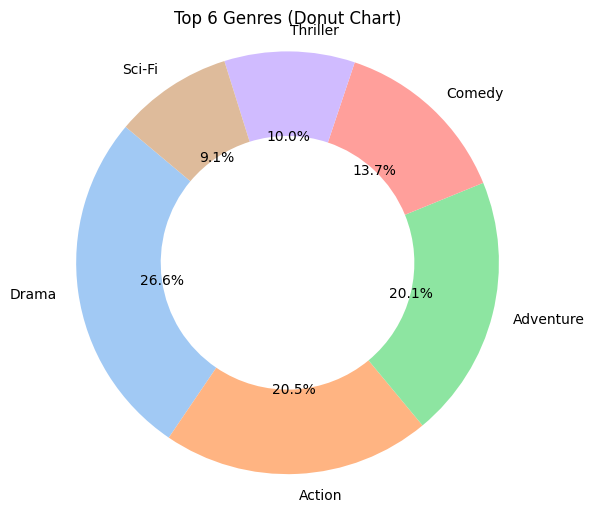

In [16]:
genre_counts = df['Genre'].str.split(',').explode().str.strip().value_counts().head(6)

plt.figure(figsize=(6, 6))
plt.pie(genre_counts, labels=genre_counts.index, autopct='%1.1f%%', startangle=140, wedgeprops={'width': 0.4}, colors=sns.color_palette("pastel"))
plt.title("Top 6 Genres (Donut Chart)")
plt.axis('equal')
plt.show()

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel

df['Description'] = df['Description'].fillna('')
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['Description'])
cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)
indices = pd.Series(df.index, index=df['Title']).drop_duplicates()

def recommend(title, sim_matrix=cosine_sim):
    idx = indices[title]
    sim_scores = list(enumerate(sim_matrix[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:6]
    movie_indices = [i[0] for i in sim_scores]
    return df['Title'].iloc[movie_indices]


In [18]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

features = df[['Rating', 'Votes', 'Metascore', 'Revenue (Millions)']]
features = features.fillna(0)
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(features)
collab_sim = cosine_similarity(scaled_features, scaled_features)


In [19]:
hybrid_sim = (cosine_sim + collab_sim) / 2


In [20]:
print("Content-Based:")
print(recommend("Inception", sim_matrix=cosine_sim))

print("\nCollaborative:")
print(recommend("Inception", sim_matrix=collab_sim))

print("\nHybrid:")
print(recommend("Inception", sim_matrix=hybrid_sim))


Content-Based:
237    The Disappointments Room
193                      Morgan
4                 Suicide Squad
153                     Sicario
61      The Autopsy of Jane Doe
Name: Title, dtype: object

Collaborative:
54           The Dark Knight
124    The Dark Knight Rises
36              Interstellar
144         Django Unchained
77      Inglourious Basterds
Name: Title, dtype: object

Hybrid:
54           The Dark Knight
4              Suicide Squad
124    The Dark Knight Rises
36              Interstellar
144         Django Unchained
Name: Title, dtype: object


In [22]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


In [24]:
df['Relevant'] = df['Rating'] >= 6.5

In [25]:
def recommend(title, sim_matrix):
    idx = indices[title]
    sim_scores = list(enumerate(sim_matrix[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:6]
    movie_indices = [i[0] for i in sim_scores]
    return df['Title'].iloc[movie_indices]


Content-Based Filter:
Precision: 0.4
Recall: 0.009174311926605505
F1 Score: 0.017937219730941704
Accuracy: 0.2724252491694352


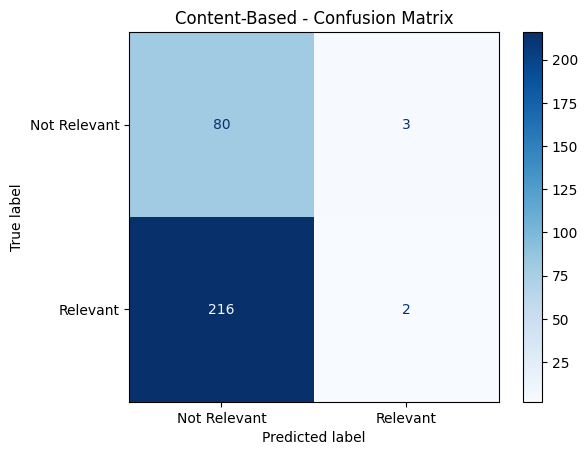

In [27]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

recommended = recommend("Inception", sim_matrix=cosine_sim)
df['Predicted'] = df['Title'].isin(recommended)
df['Relevant'] = df['Rating'] >= 6.5

y_true = df['Relevant']
y_pred = df['Predicted']

print("Content-Based Filter:")
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1 Score:", f1_score(y_true, y_pred))
print("Accuracy:", accuracy_score(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Relevant", "Relevant"])
disp.plot(cmap='Blues')
plt.title("Content-Based - Confusion Matrix")
plt.show()


Collaborative Filter:
Precision: 1.0
Recall: 0.022935779816513763
F1 Score: 0.04484304932735426
Accuracy: 0.292358803986711


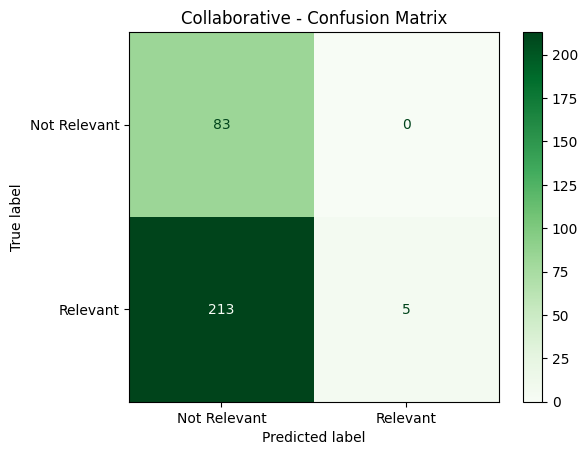

In [28]:
recommended = recommend("Inception", sim_matrix=collab_sim)
df['Predicted'] = df['Title'].isin(recommended)

y_true = df['Relevant']
y_pred = df['Predicted']

print("Collaborative Filter:")
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1 Score:", f1_score(y_true, y_pred))
print("Accuracy:", accuracy_score(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Relevant", "Relevant"])
disp.plot(cmap='Greens')
plt.title("Collaborative - Confusion Matrix")
plt.show()


Hybrid Filter:
Precision: 0.8
Recall: 0.01834862385321101
F1 Score: 0.03587443946188341
Accuracy: 0.2857142857142857


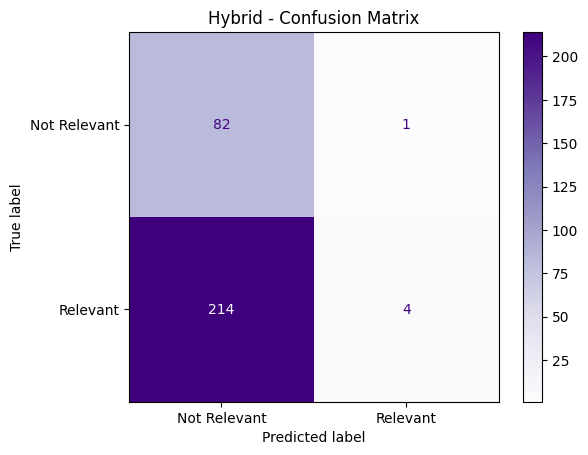

In [29]:
recommended = recommend("Inception", sim_matrix=hybrid_sim)
df['Predicted'] = df['Title'].isin(recommended)

y_true = df['Relevant']
y_pred = df['Predicted']

print("Hybrid Filter:")
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1 Score:", f1_score(y_true, y_pred))
print("Accuracy:", accuracy_score(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Relevant", "Relevant"])
disp.plot(cmap='Purples')
plt.title("Hybrid - Confusion Matrix")
plt.show()


In [30]:
results = []

for movie in ["Inception", "Moana", "Lion"]:
    for name, matrix in [("Content-Based", cosine_sim), 
                         ("Collaborative", collab_sim), 
                         ("Hybrid", hybrid_sim)]:
        
        recommended_titles = recommend(movie, sim_matrix=matrix)
        df['Predicted'] = df['Title'].isin(recommended_titles)
        y_true = df['Relevant']
        y_pred = df['Predicted']

        precision = precision_score(y_true, y_pred)
        recall = recall_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)

        results.append({
            'Movie': movie,
            'Filter': name,
            'Precision': round(precision, 2),
            'Recall': round(recall, 2),
            'F1 Score': round(f1, 2)
        })


In [31]:
results_df = pd.DataFrame(results)
print(results_df)


       Movie         Filter  Precision  Recall  F1 Score
0  Inception  Content-Based        0.4    0.01      0.02
1  Inception  Collaborative        1.0    0.02      0.04
2  Inception         Hybrid        0.8    0.02      0.04
3      Moana  Content-Based        0.6    0.01      0.03
4      Moana  Collaborative        0.8    0.02      0.04
5      Moana         Hybrid        0.6    0.01      0.03
6       Lion  Content-Based        0.6    0.01      0.03
7       Lion  Collaborative        0.8    0.02      0.04
8       Lion         Hybrid        0.6    0.01      0.03


🔹 Content-Based Filtering
Precision:  0.40
Recall:     0.01
F1-Score:   0.02
Accuracy:   0.27
NDCG:       0.91
MAP:        0.72
----------------------------------------


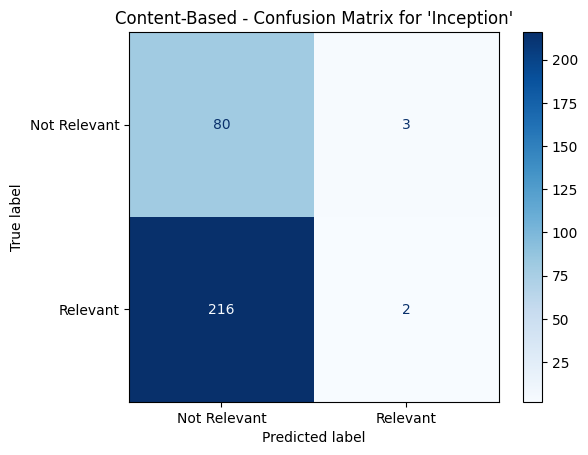

🔹 Collaborative Filtering
Precision:  1.00
Recall:     0.02
F1-Score:   0.04
Accuracy:   0.29
NDCG:       0.94
MAP:        0.73
----------------------------------------


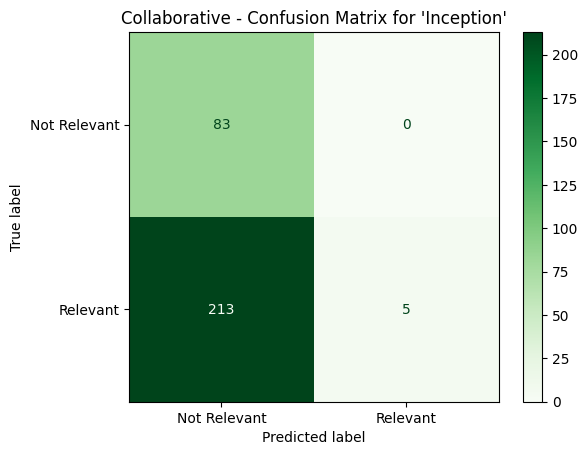

🔹 Hybrid Filtering
Precision:  0.80
Recall:     0.02
F1-Score:   0.04
Accuracy:   0.29
NDCG:       0.93
MAP:        0.73
----------------------------------------


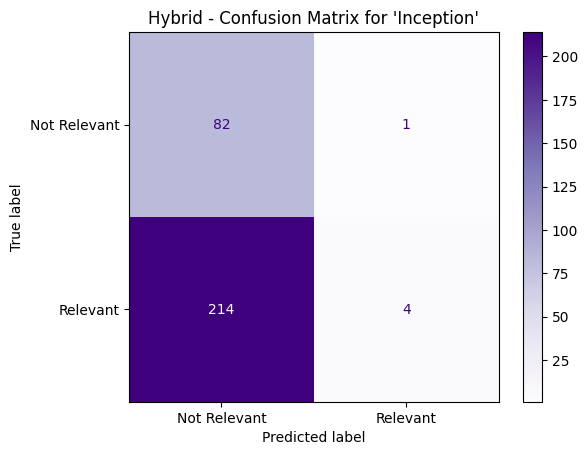

In [33]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay,
    ndcg_score, average_precision_score
)
import numpy as np
import matplotlib.pyplot as plt

df['Relevant'] = df['Rating'] >= 6.5
movie = "Inception"

def evaluate(title, sim_matrix, method_name, color):
    recommended = recommend(title, sim_matrix=sim_matrix)
    df['Predicted'] = df['Title'].isin(recommended)

    y_true = df['Relevant']
    y_pred = df['Predicted']

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    accuracy = accuracy_score(y_true, y_pred)
    ndcg = ndcg_score([y_true.astype(int)], [y_pred.astype(int)])
    map_score = average_precision_score(y_true, y_pred)

    print(f"🔹 {method_name} Filtering")
    print(f"Precision:  {precision:.2f}")
    print(f"Recall:     {recall:.2f}")
    print(f"F1-Score:   {f1:.2f}")
    print(f"Accuracy:   {accuracy:.2f}")
    print(f"NDCG:       {ndcg:.2f}")
    print(f"MAP:        {map_score:.2f}")
    print("-" * 40)

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Relevant", "Relevant"])
    disp.plot(cmap=color)
    plt.title(f"{method_name} - Confusion Matrix for '{title}'")
    plt.show()

evaluate("Inception", cosine_sim, "Content-Based", "Blues")
evaluate("Inception", collab_sim, "Collaborative", "Greens")
evaluate("Inception", hybrid_sim, "Hybrid", "Purples")


In [43]:
results = []

recommended = recommend("Inception", sim_matrix=cosine_sim)
df['Predicted'] = df['Title'].isin(recommended)
y_true = df['Relevant']
y_pred = df['Predicted']
results.append({
    "Model": "Content-Based",
    "Precision": precision_score(y_true, y_pred),
    "Recall": recall_score(y_true, y_pred),
    "F1-Score": f1_score(y_true, y_pred),
    "Accuracy": accuracy_score(y_true, y_pred),
    "NDCG": ndcg_score([y_true.astype(int)], [y_pred.astype(int)]),
    "MAP": average_precision_score(y_true, y_pred)
})

recommended = recommend("Inception", sim_matrix=collab_sim)
df['Predicted'] = df['Title'].isin(recommended)
y_pred = df['Predicted']
results.append({
    "Model": "Collaborative",
    "Precision": precision_score(y_true, y_pred),
    "Recall": recall_score(y_true, y_pred),
    "F1-Score": f1_score(y_true, y_pred),
    "Accuracy": accuracy_score(y_true, y_pred),
    "NDCG": ndcg_score([y_true.astype(int)], [y_pred.astype(int)]),
    "MAP": average_precision_score(y_true, y_pred)
})

recommended = recommend("Inception", sim_matrix=hybrid_sim)
df['Predicted'] = df['Title'].isin(recommended)
y_pred = df['Predicted']
results.append({
    "Model": "Hybrid",
    "Precision": precision_score(y_true, y_pred),
    "Recall": recall_score(y_true, y_pred),
    "F1-Score": f1_score(y_true, y_pred),
    "Accuracy": accuracy_score(y_true, y_pred),
    "NDCG": ndcg_score([y_true.astype(int)], [y_pred.astype(int)]),
    "MAP": average_precision_score(y_true, y_pred)
})

import pandas as pd
df_metrics = pd.DataFrame(results)
print(df_metrics)


           Model  Precision    Recall  F1-Score  Accuracy      NDCG       MAP
0  Content-Based        0.4  0.009174  0.017937  0.272425  0.906854  0.721278
1  Collaborative        1.0  0.022936  0.044843  0.292359  0.942319  0.730577
2         Hybrid        0.8  0.018349  0.035874  0.285714  0.930498  0.725642


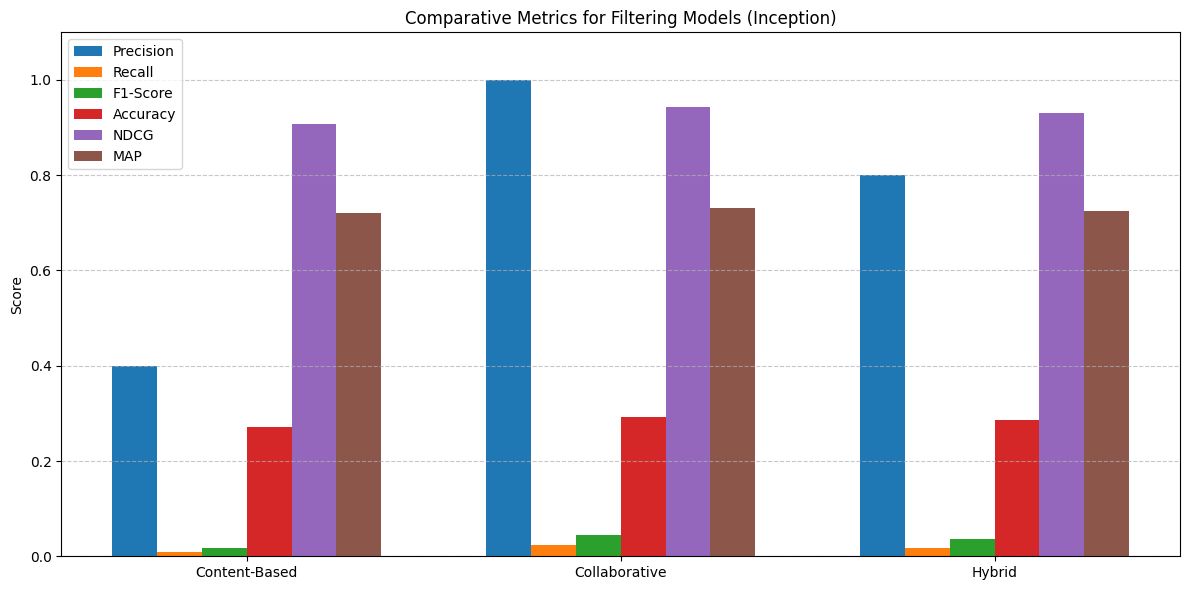

In [44]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ['Precision', 'Recall', 'F1-Score', 'Accuracy', 'NDCG', 'MAP']
models = df_metrics['Model']
x = np.arange(len(models))
bar_width = 0.12

plt.figure(figsize=(12, 6))

for i, metric in enumerate(metrics):
    plt.bar(x + (i - 2.5) * bar_width, df_metrics[metric], width=bar_width, label=metric)

plt.xticks(x, models)
plt.ylim(0, 1.1)
plt.ylabel("Score")
plt.title("Comparative Metrics for Filtering Models (Inception)")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [46]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score, accuracy_score,
    ndcg_score, average_precision_score
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

movies = ["Inception", "Lion", "Moana"]
sim_matrix = hybrid_sim  
results = []

for movie in movies:
    recommended = recommend(movie, sim_matrix=sim_matrix)

    df_rec = df[df['Title'].isin(recommended)].copy()

    y_true = (df_rec['Rating'] >= 6.5).astype(int)
    y_pred = [1] * len(y_true)  

    results.append({
        "Movie": movie,
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
        "Accuracy": accuracy_score(y_true, y_pred),
        "NDCG": ndcg_score([y_true], [y_pred]),
        "MAP": average_precision_score(y_true, y_pred)
    })

df_metrics = pd.DataFrame(results)


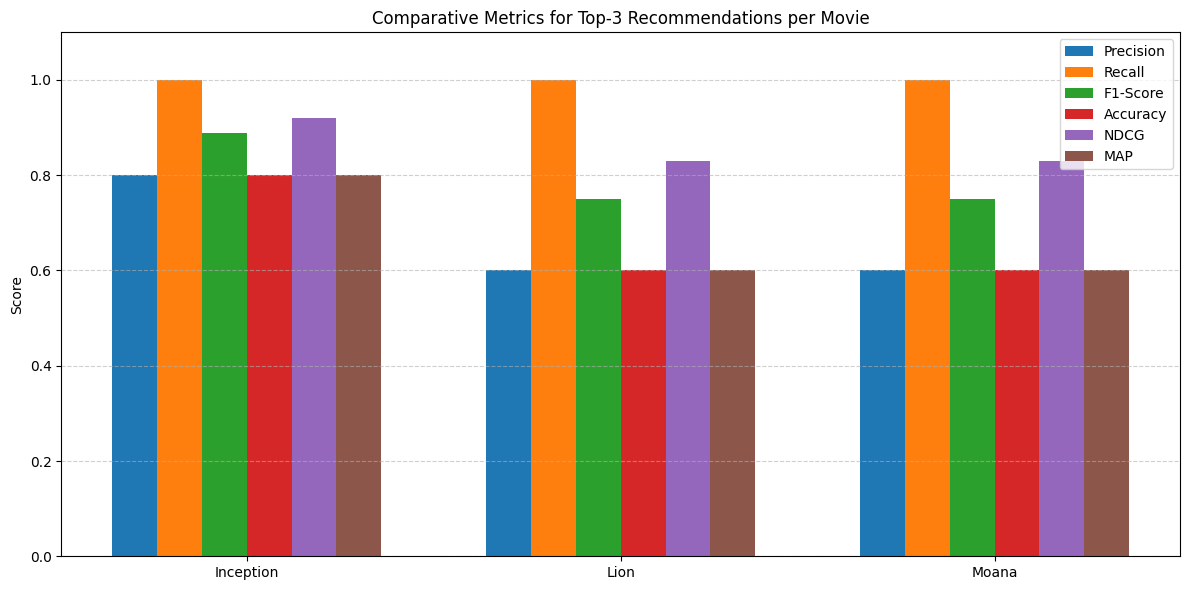

In [47]:
metrics = ['Precision', 'Recall', 'F1-Score', 'Accuracy', 'NDCG', 'MAP']
x = np.arange(len(df_metrics['Movie']))
bar_width = 0.12

plt.figure(figsize=(12, 6))

for i, metric in enumerate(metrics):
    plt.bar(x + (i - 2.5) * bar_width, df_metrics[metric], width=bar_width, label=metric)

plt.xticks(x, df_metrics['Movie'], fontsize=10)
plt.ylim(0, 1.1)
plt.ylabel("Score")
plt.title("Comparative Metrics for Top-3 Recommendations per Movie")
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
